## NBA Free Agency Analysis

## Question: Does NBA Free Agency spending impact team performance?

## Motivation: Free agency spending is often viewed as a way for NBA teams to improve performance, but its actual impact is uncertain.

## Method: I collected data on team free agency spending and win percentages for the top 10 NBA teams by spending following the 2024–2025 season. I created a performance improvement metric by comparing each team’s win percentage before and after free agency. I then used correlation and linear regression to analyze the relationship between spending and both team performance and improvement. This approach allows for comparison between expected and actual performance outcomes.

# Data Gathering

In [56]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

df = pd.read_csv("data/NBA_free_agency_win_percentage.csv")

df["Value"] = (
    df["Value"]
    .str.replace(r"[^\d.]", "", regex=True)
    .astype(float)
)

df["Win % Change"] = df["Win % This Year"] - df["Win % Last Year"]

df

,Teams,Value,Wins Last Year,Loses Last Year,Win % Last Year,Wins This Year,Loses This Year,Win % This Year,Win % Change
0,Milwaukee,205243383.0,48,34,0.585,32,50,0.390,-0.195
1,Dallas,138354796.0,39,43,0.476,26,56,0.317,-0.159
2,Houston,133193021.0,52,30,0.634,52,30,0.634,0.000
3,Chicago,129459791.0,39,43,0.476,31,51,0.378,-0.098
4,Memphis,93018133.0,48,34,0.585,25,57,0.305,-0.280
5,Detroit,90705090.0,44,38,0.537,60,22,0.732,0.195
6,Atlanta,78568247.0,40,42,0.488,46,36,0.561,0.073
7,Golden State,71924877.0,48,34,0.585,37,45,0.451,-0.134
8,San Antonio,54427789.0,34,48,0.415,62,20,0.756,0.341
9,Sacramento,51695906.0,40,42,0.488,22,60,0.268,-0.220


In [57]:
df.rename(columns={"Value": "Spending"}, inplace=True)

df

,Teams,Spending,Wins Last Year,Loses Last Year,Win % Last Year,Wins This Year,Loses This Year,Win % This Year,Win % Change
0,Milwaukee,205243383.0,48,34,0.585,32,50,0.390,-0.195
1,Dallas,138354796.0,39,43,0.476,26,56,0.317,-0.159
2,Houston,133193021.0,52,30,0.634,52,30,0.634,0.000
3,Chicago,129459791.0,39,43,0.476,31,51,0.378,-0.098
4,Memphis,93018133.0,48,34,0.585,25,57,0.305,-0.280
5,Detroit,90705090.0,44,38,0.537,60,22,0.732,0.195
6,Atlanta,78568247.0,40,42,0.488,46,36,0.561,0.073
7,Golden State,71924877.0,48,34,0.585,37,45,0.451,-0.134
8,San Antonio,54427789.0,34,48,0.415,62,20,0.756,0.341
9,Sacramento,51695906.0,40,42,0.488,22,60,0.268,-0.220


# Results

### Spending vs Performance

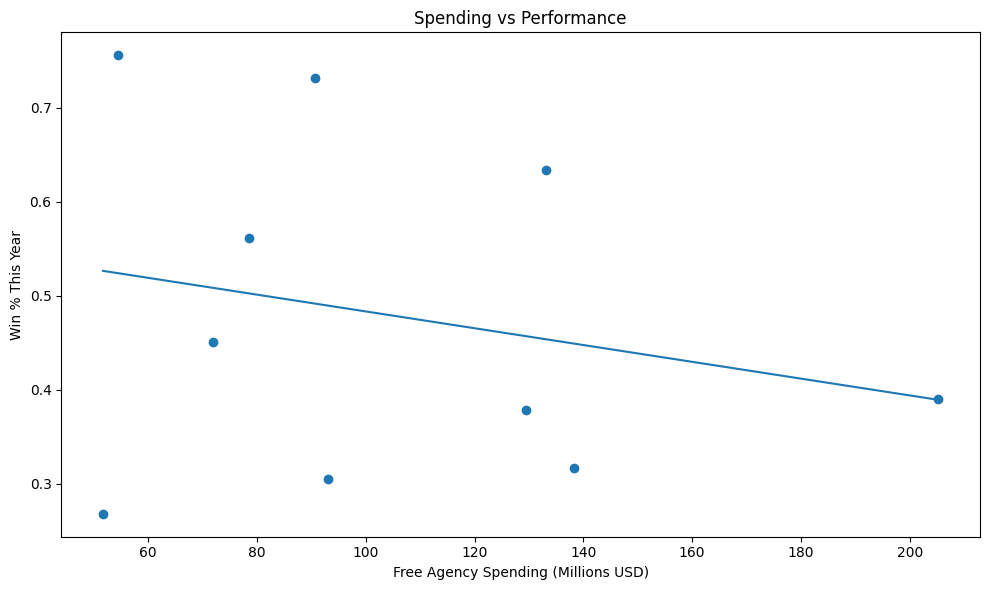

In [58]:
import numpy as np

df["Spending_M"] = df["Spending"] / 1000000

x = df["Spending_M"]
y = df["Win % This Year"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(10,6))
plt.scatter(x, y)
plt.plot(x, m*x + b)

plt.xlabel("Free Agency Spending (Millions USD)")
plt.ylabel("Win % This Year")
plt.title("Spending vs Performance")

plt.tight_layout()

plt.show()

In [59]:
df["Spending"].corr(df["Win % This Year"])

np.float64(-0.23469466320687835)

A weak negative correlation (r ≈ -0.23) was observed between free agency spending and team performance, suggesting that higher spending does not guarantee better results.

This suggests that factors such as team chemistry, injuries, and roster composition may play a significant role in determining team performance.

### Spending vs. Improvement

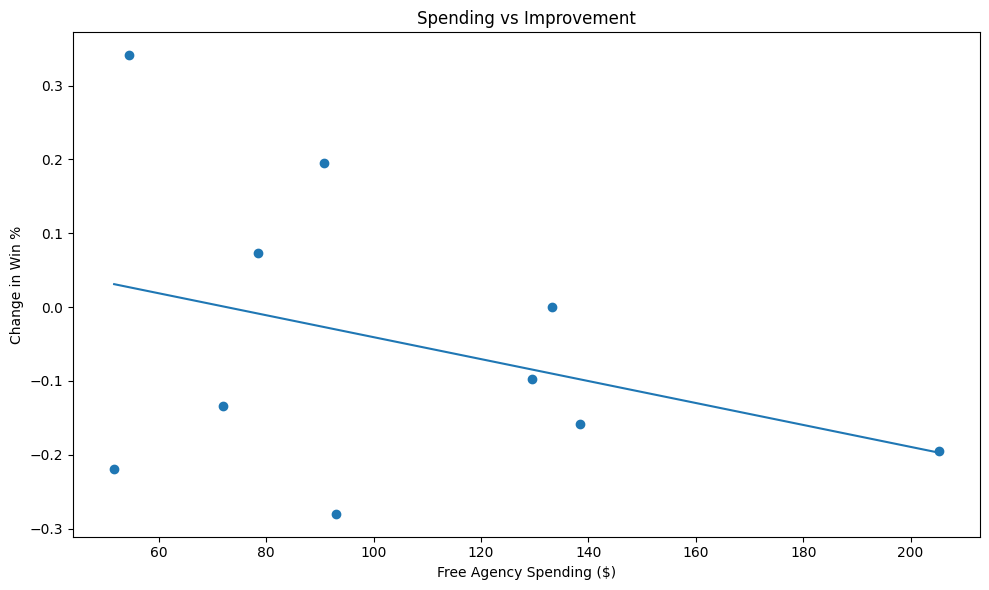

In [60]:
import matplotlib.pyplot as plt
import numpy as np

df["Spending_M"] = df["Spending"] / 1000000

x = df["Spending_M"]
y = df["Win % Change"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(10, 6))
plt.scatter(x, y)
plt.plot(x, m*x + b)

plt.xlabel("Free Agency Spending ($)")
plt.ylabel("Change in Win %")
plt.title("Spending vs Improvement")

plt.tight_layout()

plt.show()

In [61]:
df["Spending"].corr(df["Win % Change"])

np.float64(-0.3537662203214714)

The analysis found a moderate negative correlation (r ≈ -0.35) between free agency spending and improvement in winning percentage. This indicates that higher spending is not associated with greater team improvement and may reflect inefficiencies in how teams allocate resources.

This trend may be influenced by weaker teams spending more aggressively in free agency, while stronger teams rely less on external acquisitions.

### Outliers

Outliers are defined as teams with |residual| > 0.05.

#### Teams that Peformed Better Than Expected

In [62]:
df["Predicted Win %"] = m * df["Spending"] + b
df["Residual"] = df["Win % This Year"] - df["Predicted Win %"]

df[df["Residual"] > 0.05].sort_values("Residual", ascending=False)

,Teams,Spending,Wins Last Year,Loses Last Year,Win % Last Year,Wins This Year,Loses This Year,Win % This Year,Win % Change,Spending_M,Predicted Win %,Residual
0,Milwaukee,205243383.0,48,34,0.585,32,50,0.390,-0.195,205.243383,-305003.316686,305003.706686
1,Dallas,138354796.0,39,43,0.476,26,56,0.317,-0.159,138.354796,-205603.044688,205603.361688
2,Houston,133193021.0,52,30,0.634,52,30,0.634,0.000,133.193021,-197932.351345,197932.985345
3,Chicago,129459791.0,39,43,0.476,31,51,0.378,-0.098,129.459791,-192384.557707,192384.935707
4,Memphis,93018133.0,48,34,0.585,25,57,0.305,-0.280,93.018133,-138230.166357,138230.471357
5,Detroit,90705090.0,44,38,0.537,60,22,0.732,0.195,90.705090,-134792.851956,134793.583956
6,Atlanta,78568247.0,40,42,0.488,46,36,0.561,0.073,78.568247,-116756.807999,116757.368999
7,Golden State,71924877.0,48,34,0.585,37,45,0.451,-0.134,71.924877,-106884.379613,106884.830613
8,San Antonio,54427789.0,34,48,0.415,62,20,0.756,0.341,54.427789,-80882.704523,80883.460523
9,Sacramento,51695906.0,40,42,0.488,22,60,0.268,-0.220,51.695906,-76822.969889,76823.237889


#### Teams that Underperformed

In [63]:
df[df["Residual"] < -0.05].sort_values("Residual")

,Teams,Spending,Wins Last Year,Loses Last Year,Win % Last Year,Wins This Year,Loses This Year,Win % This Year,Win % Change,Spending_M,Predicted Win %,Residual


The following plots highlight teams that significantly deviated from expected performance based on their free agency spending.

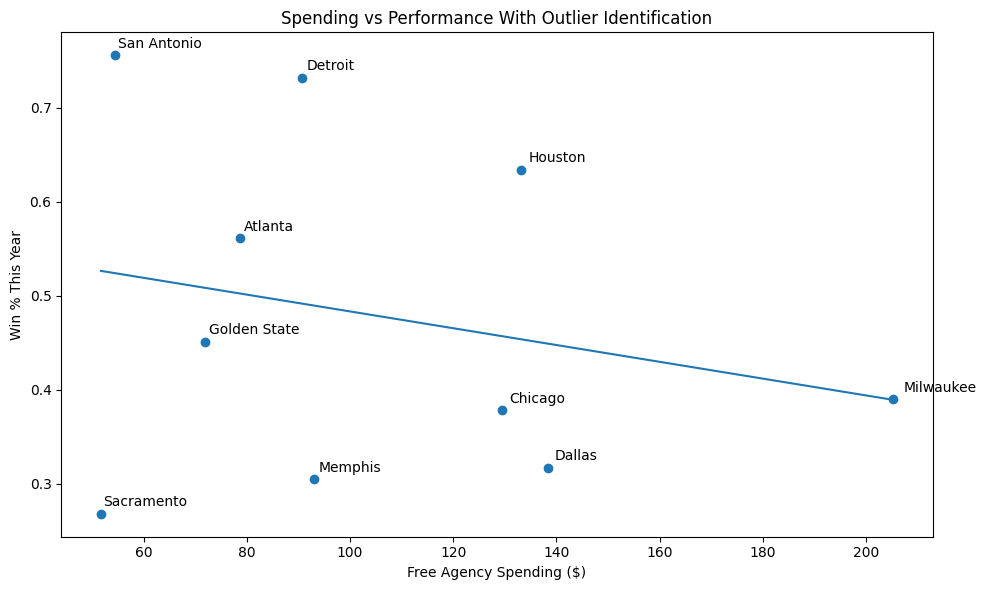

In [64]:
import numpy as np

df["Spending_M"] = df["Spending"] / 1000000

x = df["Spending_M"]
y = df["Win % This Year"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(10,6))
plt.scatter(x, y)
plt.plot(x, m*x + b)

plt.xlabel("Free Agency Spending ($)")
plt.ylabel("Win % This Year")
plt.title("Spending vs Performance With Outlier Identification")

for i in range(len(df)):
    if abs(df["Residual"].iloc[i]) > 0.05:
        plt.text(
            df["Spending_M"].iloc[i] * 1.01,   # small horizontal shift
            df["Win % This Year"].iloc[i] + 0.008,  # small vertical shift
            df["Teams"].iloc[i]
        )

plt.tight_layout()

plt.show()

San Antonio significantly outperformed expectations despite relatively low spending, suggesting efficient roster construction or strong internal player development.

In contrast, Sacramento underperformed dramatically, indicating that high free agency spending did not translate into improved on-court performance.

These deviations highlight that while overall trends are weak, individual team decisions can significantly outperform or underperform expectations.

# Conclusion

Free agency spending alone is not a reliable predictor of team performance or improvement in the NBA. The analysis showed weak to moderate negative relationships between spending and both performance and improvement, suggesting that higher spending does not guarantee success.

Some teams significantly outperformed or underperformed expectations, highlighting that factors beyond financial investment—such as team chemistry, player development, and injuries—play a major role in determining outcomes.

Some limitations of this analysis include limited sample size with teams as well as years utilized. Future analysis could incorporate additional variables such as player efficiency metrics, roster continuity, or injury data to better explain team performance.